# ANN-NARX on REAL Ball-and-Beam Data (multisine_05)

Notebook version of `ann_narx_ball_and_beam.py`.

Neural-network NARX identification, ported from the course example

    https://helonayala.github.io/sysid/ANN_narx.html

but fed with the **real ball-and-beam data** using the exact same input values
defined in A2 (activity_ball_and_beam_RLS.py) and reused in A3
(narmax_ball_and_beam.py):

    experiment       = 'multisine_05'
    resample_factor  = 50            -> Ts = 0.05 s
    y_dot_method     = 'savgol'
    train/test split = 50 / 50
    NARX orders      = ny = 2, nu = 2   (same as the previous ARX models)

Key addition vs. the original ANN_narx.html code
-------------------------------------------------
The Narendra benchmark in the reference page is generated directly in the
range ~[-1, 1], so the author feeds the raw signals to the network without
any scaling.  The ball-and-beam signals live in arbitrary physical units, so
here we add a **min-max normalisation to [0, 1]** (fitted on the TRAIN half
only, then applied to both halves) before building the NARX regressors.  This
is exactly the "normalize to 0..1" step that the original code omits.  R^2 is
invariant under this affine scaling, so the reported metrics are identical in
normalised or physical units; predictions are de-normalised before plotting.

Network / training (kept identical to the reference)
----------------------------------------------------
    3 hidden layers x 80 neurons, SELU activations, Kaiming/LeCun init,
    NAdam(lr=1e-3), MSE loss, mini-batches of 32.
The only training knob raised is the epoch count, because the ball-and-beam
record is far shorter than the 50k-sample Narendra set.

Requires:  torch, bab_datasets, scikit-learn
    pip install --upgrade git+https://github.com/helonayala/bab_datasets.git

Run with:  python ann_narx_ball_and_beam.py

## Imports and setup

In [ ]:
import os

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

HERE = os.path.abspath(os.path.dirname("__file__") or os.getcwd())

try:
    import bab_datasets as nod
except ImportError as exc:  # pragma: no cover
    raise SystemExit(
        "The 'bab_datasets' package is required.\n"
        "Install it with:\n"
        "    pip install --upgrade git+https://github.com/helonayala/bab_datasets.git"
    ) from exc

## Reproducibility (same seed as the reference page)

In [ ]:
RSEED = 42
np.random.seed(RSEED)
torch.manual_seed(RSEED)
np.set_printoptions(precision=3)

## Configuration  (the "previously used input values" for ball-and-beam)

In [ ]:
EXPERIMENT = "multisine_05"
RESAMPLE_FACTOR = 50
Y_DOT_METHOD = "savgol"
TRAIN_FRACTION = 0.5

NY, NU = 2, 2          # NARX lag orders (match the previous ARX: n_a = n_b = 2)

NNEU = 80              # neurons per hidden layer (reference value)
EPOCHS = 300           # raised from 3: the BaB record is much shorter than Narendra
BATCH_SIZE = 32
LR = 1e-3

## NARX helpers (verbatim from ANN_narx.html)

In [ ]:
def matReg(y, u, ny, nu):
    p = np.max((ny, nu)) + 1
    (N, ) = y.shape
    (Nu, ) = u.shape

    if N != Nu:
        print('Dimensions of u and y vector are not consistent')
        return (-1, -1)

    target = y[p - 1:N]

    Phi = np.zeros((N - p + 1, ny + nu))
    for i in range(ny):
        Phi[:, i] = y[p - i - 2: N - i - 1]

    for i in range(nu):
        Phi[:, i + ny] = u[p - i - 2: N - i - 1]

    return (target, Phi)

In [ ]:
def freeRun(model, y, u, ny, nu):
    p = max(ny, nu) + 1
    (N, ) = y.shape

    yhat = np.zeros(N)
    yhat[:p - 1] = y[:p - 1]

    for k in range(p, N + 1):
        auxY = np.concatenate((yhat[(k - p):(k - 1)], (0, )), axis=0)
        auxU = np.concatenate((u[(k - p):(k - 1)], (0, )), axis=0)

        _, fr_input = matReg(auxY, auxU, ny, nu)
        yhat[k - 1] = model.predict(torch.tensor(fr_input, dtype=torch.float32))
    return yhat[-(N - p + 1):]

## Min-max normalisation to [0, 1]  (the step missing in the reference code)

In [ ]:
def fit_minmax(x):
    """Return (lo, hi) of a 1-D signal."""
    return float(np.min(x)), float(np.max(x))

In [ ]:
def normalize(x, lo, hi):
    return (x - lo) / (hi - lo)

In [ ]:
def denormalize(xn, lo, hi):
    return xn * (hi - lo) + lo

## Data loading (bab_datasets, identical call to A1/A2)

In [ ]:
def load_data():
    data = nod.load_experiment(
        EXPERIMENT,
        preprocess=True,
        plot=False,
        end_idx=None,
        resample_factor=RESAMPLE_FACTOR,
        zoom_last_n=10000,
        y_dot_method=Y_DOT_METHOD,
    )
    u = np.asarray(data.u, dtype=float).ravel()
    y = np.asarray(data.y, dtype=float).ravel()
    ts = float(data.sampling_time)
    return u, y, ts

## Model (verbatim architecture from ANN_narx.html)

In [ ]:
class MyModel(nn.Module):
    def __init__(self, ninp, nneu, nout):
        super(MyModel, self).__init__()
        self.hidden1 = nn.Linear(ninp, nneu)
        self.hidden2 = nn.Linear(nneu, nneu)
        self.hidden3 = nn.Linear(nneu, nneu)
        self.output = nn.Linear(nneu, nout)

        nn.init.kaiming_normal_(self.hidden1.weight, nonlinearity='selu')
        nn.init.kaiming_normal_(self.hidden2.weight, nonlinearity='selu')
        nn.init.kaiming_normal_(self.hidden3.weight, nonlinearity='selu')
        nn.init.kaiming_normal_(self.output.weight, nonlinearity='linear')

    def forward(self, x):
        x = F.selu(self.hidden1(x))
        x = F.selu(self.hidden2(x))
        x = F.selu(self.hidden3(x))
        x = self.output(x)
        return x

    def predict(self, x):
        with torch.no_grad():
            return self.forward(x)

## Main

### load + 50/50 split (same as the previous activities)

In [ ]:
u, y, ts = load_data()
n = u.size
split = int(round(TRAIN_FRACTION * n))

ue, ye = u[:split], y[:split]          # train ("estimation") half
ut, yt = u[split:], y[split:]          # test  ("validation") half

print("=" * 72)
print(f"ANN-NARX Ball-and-Beam  ('{EXPERIMENT}', Ts={ts:.4f}s)")
print("=" * 72)
print(f"total samples : {n}")
print(f"train (50%)   : {ue.size}")
print(f"test  (50%)   : {ut.size}")

### min-max normalisation to [0,1] (fit on TRAIN only)

In [ ]:
u_lo, u_hi = fit_minmax(ue)
y_lo, y_hi = fit_minmax(ye)
print(f"\nNormalisation ranges (from train half):")
print(f"  u in [{u_lo:.4g}, {u_hi:.4g}] -> [0, 1]")
print(f"  y in [{y_lo:.4g}, {y_hi:.4g}] -> [0, 1]")

ue_n, ye_n = normalize(ue, u_lo, u_hi), normalize(ye, y_lo, y_hi)
ut_n, yt_n = normalize(ut, u_lo, u_hi), normalize(yt, y_lo, y_hi)

### NARX regressors on the normalised signals

In [ ]:
(Ye, Phie) = matReg(ye_n, ue_n, NY, NU)
(Yt, Phit) = matReg(yt_n, ut_n, NY, NU)

Phie_t = torch.tensor(Phie, dtype=torch.float32)
Ye_t = torch.tensor(Ye, dtype=torch.float32)
Phit_t = torch.tensor(Phit, dtype=torch.float32)
Yt_t = torch.tensor(Yt, dtype=torch.float32)

dataloader = DataLoader(TensorDataset(Phie_t, Ye_t),
                        batch_size=BATCH_SIZE, shuffle=True)

### build + train the network

In [ ]:
_, ninp = Phie_t.shape
model = MyModel(ninp, NNEU, nout=1)
optimizer = optim.NAdam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

print(f"\nTraining ANN-NARX (ny={NY}, nu={NU}, inputs={ninp}, "
      f"{NNEU} neurons x 3 layers, {EPOCHS} epochs)...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for inputs, targets in dataloader:
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(dataloader)
    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f"  epoch {epoch + 1:4d}/{EPOCHS}  loss={epoch_loss:.3e}")
print("Training finished!")

### one-step-ahead predictions

In [ ]:
y_train_pred1 = model.predict(Phie_t).squeeze().numpy()
y_test_pred1 = model.predict(Phit_t).squeeze().numpy()
R2train1 = r2_score(Ye, y_train_pred1)
R2test1 = r2_score(Yt, y_test_pred1)

### free-run simulation (test half)

In [ ]:
y_test_pred0 = freeRun(model, yt_n, ut_n, NY, NU)
R2test0 = r2_score(Yt, y_test_pred0)

print("\n" + "-" * 40)
print("One-step-ahead   R2 train =", f"{R2train1:.4f}")
print("One-step-ahead   R2 test  =", f"{R2test1:.4f}")
print("Free-run (test)  R2 test  =", f"{R2test0:.4f}")
print("-" * 40)

### de-normalise to physical units for plotting

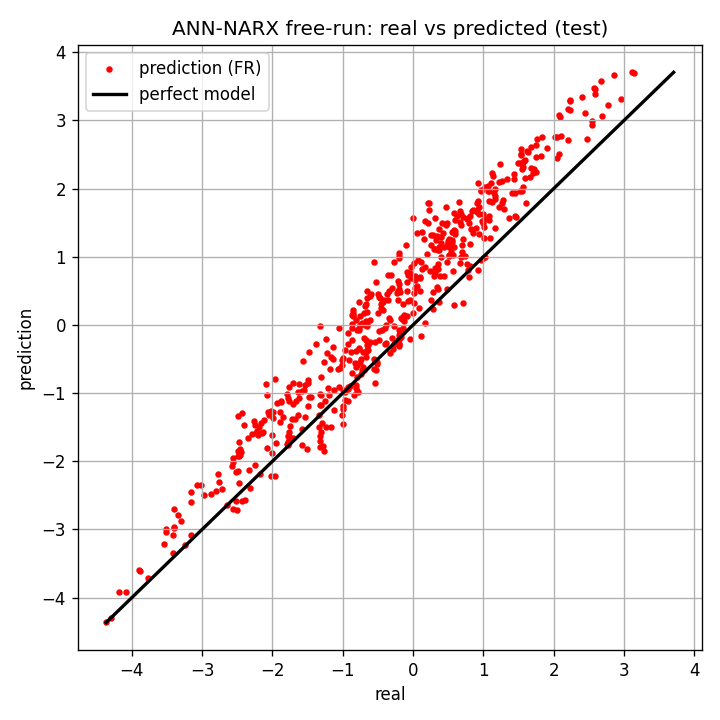

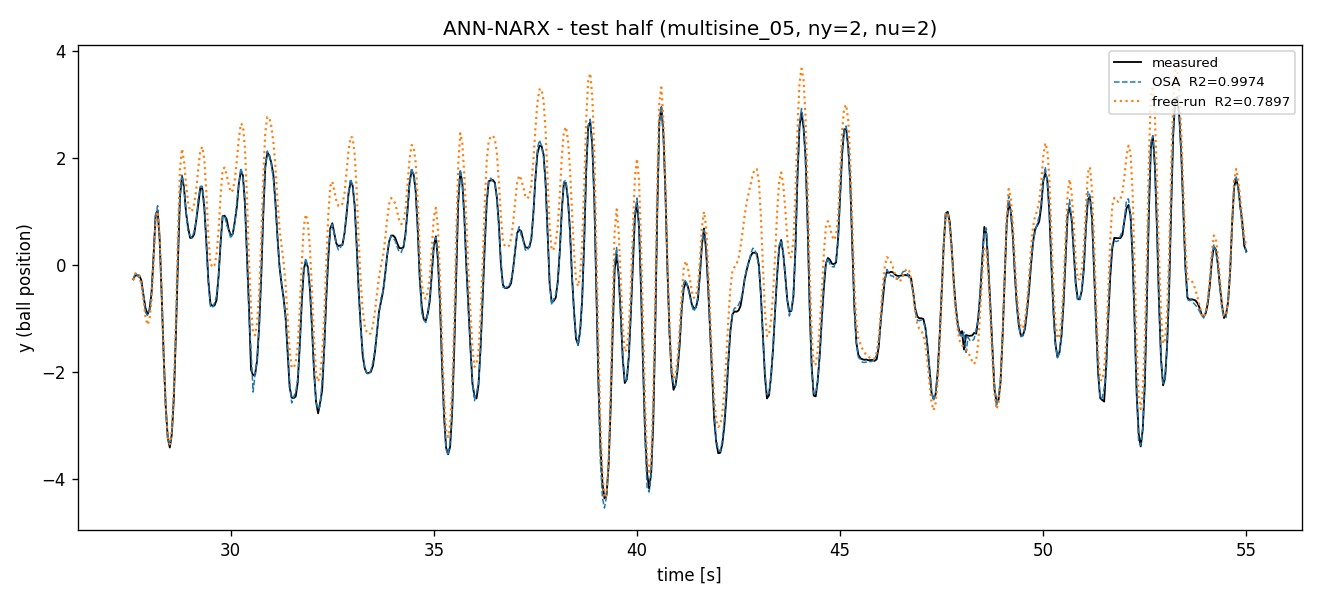

In [1]:
Yt_phys = denormalize(Yt, y_lo, y_hi)
osa_phys = denormalize(y_test_pred1, y_lo, y_hi)
fr_phys = denormalize(y_test_pred0, y_lo, y_hi)
p = max(NY, NU) + 1
t_test = (split + (p - 1) + np.arange(Yt.size)) * ts

# Figure 1: time-domain (test half) measured vs OSA vs free-run
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(t_test, Yt_phys, "k", lw=1.1, label="measured")
ax.plot(t_test, osa_phys, "--", lw=0.9, label=f"OSA  R2={R2test1:.4f}")
ax.plot(t_test, fr_phys, ":", lw=1.3, label=f"free-run  R2={R2test0:.4f}")
ax.set_title(f"ANN-NARX - test half ({EXPERIMENT}, ny={NY}, nu={NU})")
ax.set_xlabel("time [s]")
ax.set_ylabel("y (ball position)")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(HERE, "ann_narx_bab_time_domain.png"), dpi=120)

# Figure 2: real vs predicted scatter (free-run)
fig2, ax2 = plt.subplots(figsize=(6, 6))
lo = min(Yt_phys.min(), fr_phys.min())
hi = max(Yt_phys.max(), fr_phys.max())
ax2.scatter(Yt_phys, fr_phys, c="red", s=8, label="prediction (FR)")
ax2.plot([lo, hi], [lo, hi], "k", lw=2, label="perfect model")
ax2.set_xlabel("real")
ax2.set_ylabel("prediction")
ax2.set_title("ANN-NARX free-run: real vs predicted (test)")
ax2.legend()
ax2.grid(True)
fig2.tight_layout()
fig2.savefig(os.path.join(HERE, "ann_narx_bab_scatter.png"), dpi=120)

print("\nSaved figures: ann_narx_bab_time_domain.png, ann_narx_bab_scatter.png")
# plt.show()  # uncomment for interactive display